# A Hidden Markov Model framework for m6A detection from GLORI-seq

This notebook implements and validates the per-nucleotide HMM described in
the manuscript. The model defines a hidden state at every transcript position
$Z_t \in \{U, M, B\}$ and emits a beta-binomial conversion-count observation
together with a DRACH/non-DRACH context indicator at adenosine positions only.

The notebook is organised as follows:

1.  **Model**: per-nucleotide forward–backward, Viterbi, beta-binomial emission, numerical MLE for the dispersion.
2.  **Baum–Welch training**: with monotonicity check, state-ordering constraint, and Dirichlet pseudocounts.
3.  **Synthetic GLORI-seq simulator**:realistic enough to allow ground-truth evaluation.
4.  **Validation suite**:
   - 4.1 Sanity check on the forward–backward algorithm (likelihood = $\sum$ joint).
   - 4.2 Parameter recovery from simulated data.
   - 4.3 Convergence diagnostics (monotonic log-likelihood, multi-start stability).
   - 4.4 ROC/PR/F1 with bootstrap confidence intervals.
   - 4.5 Threshold sweep and operating-point analysis.
   - 4.6 Stratified evaluation (coverage, DRACH vs. non-DRACH, in vs. out of artifact).
   - 4.7 Ablation: no artifact state, no DRACH emission, binomial instead of beta-binomial.
   - 4.8 Posterior calibration.
   - 4.9 Robustness to misspecification (varying artifact rate/m6A rate/overdispersion).
   - 4.10 Comparison to the binomial-baseline caller (per-gene background, BH-FDR).

## 1. Imports and setup

In [1]:
import numpy as np
import pandas as pd
from scipy.special import gammaln, logsumexp
from scipy.stats import binom
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from dataclasses import dataclass, field, replace
from typing import Optional, List, Tuple

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140})


## 2. Per-nucleotide HMM

### 2.1 Parameter container

State indexing: `0 = U` (unmethylated / clean background), `1 = M` (true m6A),
`2 = B` (artifact / poor-conversion). The state-ordering constraint
$\mu_U < \mu_B < \mu_M$ is enforced after every M-step (Section 2.14 of the
paper).

In [2]:
@dataclass
class HMMParams:
    pi: np.ndarray # (3,) start probabilities
    T:  np.ndarray # (3, 3) transition matrix, rows sum to 1
    mu: np.ndarray # (3,) state-specific A-retention means
    kappa: np.ndarray # (3,) state-specific beta-binomial concentration
    p_drach: np.ndarray # (3,) P(DRACH | state)

    @staticmethod
    def default():
        return HMMParams(
            pi=np.array([0.95, 0.02, 0.03]),
            T=np.array([
                [0.985, 0.005, 0.010], # from U: stay clean
                [0.300, 0.650, 0.050], # from M: short m6A runs
                [0.100, 0.020, 0.880], # from B: longer artifact stretches
            ]),
            mu=np.array([0.03, 0.65, 0.25]),
            kappa=np.array([60.0, 30.0, 25.0]),
            p_drach=np.array([0.30, 0.85, 0.30]),
        )

    def alpha_beta(self):
        a = self.mu * self.kappa
        b = (1 - self.mu) * self.kappa
        return a, b

    def copy(self):
        return HMMParams(
            pi=self.pi.copy(), T=self.T.copy(),
            mu=self.mu.copy(), kappa=self.kappa.copy(),
            p_drach=self.p_drach.copy(),
        )


### 2.2 Beta-binomial log-PMF

$$\log P(k \mid n, \alpha, \beta) =
\log\binom{n}{k} + \log B(k+\alpha, n-k+\beta) - \log B(\alpha, \beta).$$


In [3]:
def log_betabinom_pmf(k, n, a, b):
    '''Vectorised log P(k | n, alpha, beta).'''
    return (gammaln(n + 1) - gammaln(k + 1) - gammaln(n - k + 1)
            + gammaln(k + a) + gammaln(n - k + b) - gammaln(n + a + b)
            + gammaln(a + b) - gammaln(a) - gammaln(b))


### 2.3 Transcript container and emission log-probabilities

The log-emission at non-A positions is `0` (neutral), as required by Section 2.5
of the paper. Only the transition structure carries information across non-A spacers.

In [4]:
@dataclass
class Transcript:
    seq: str                 # reference, characters in {A,C,G,T}
    A_idx: np.ndarray        # adenosine positions (sorted)
    n: np.ndarray            # informative coverage at each position (0 for non-A)
    A_count: np.ndarray      # A-like reads at each position (0 for non-A)
    drach: np.ndarray        # bool, DRACH motif at each position (False at non-A)
    truth_m6a: np.ndarray    # bool, simulation ground truth (None for real data)
    truth_artifact: np.ndarray  # bool, simulation ground truth (None for real data)


def emission_logprob(tr: Transcript, params: HMMParams) -> np.ndarray:
    '''
    Return log P(O_t | Z_t = z) of shape (L, 3).
    Non-A positions get a neutral 0 across all states.
    '''
    L = len(tr.seq)
    K = 3
    a, b = params.alpha_beta()
    log_e = np.zeros((L, K))
    if len(tr.A_idx) == 0:
        return log_e
    A_idx = tr.A_idx
    k = tr.A_count[A_idx] # (n_A,)
    n = tr.n[A_idx] # (n_A,)
    drach = tr.drach[A_idx] # (n_A,)
    # beta-binomial term: (n_A, K)
    bb = np.empty((len(A_idx), K))
    for z in range(K):
        bb[:, z] = log_betabinom_pmf(k, n, a[z], b[z])
    # DRACH emission term: (n_A, K)
    log_p_d  = np.log(params.p_drach + 1e-300)
    log_p_nd = np.log(1 - params.p_drach + 1e-300)
    ctx = np.where(drach[:, None], log_p_d[None, :], log_p_nd[None, :])
    log_e[A_idx] = bb + ctx
    return log_e


### 2.4 Forward–backward and Viterbi

Standard log-space implementations. `forward_backward` returns
$\log\alpha$, $\log\beta$, $\log\gamma$, and $\log Z$ (the log-likelihood).

In [5]:
def forward_backward(log_e: np.ndarray, log_pi: np.ndarray, log_T: np.ndarray):
    '''
    log_e:  (L, K)  log emission probabilities
    log_pi: (K,)    log start probabilities
    log_T:  (K, K)  log transition matrix
    Returns log_alpha, log_beta, log_gamma, log_Z.
    '''
    L, K = log_e.shape
    log_alpha = np.full((L, K), -np.inf)
    log_alpha[0] = log_pi + log_e[0]
    for t in range(1, L):
        log_alpha[t] = logsumexp(log_alpha[t - 1][:, None] + log_T, axis=0) + log_e[t]
    log_beta = np.full((L, K), -np.inf)
    log_beta[-1] = 0.0
    for t in range(L - 2, -1, -1):
        log_beta[t] = logsumexp(log_T + (log_e[t + 1] + log_beta[t + 1])[None, :], axis=1)
    log_Z = logsumexp(log_alpha[-1])
    log_gamma = log_alpha + log_beta - log_Z
    return log_alpha, log_beta, log_gamma, log_Z


def viterbi(log_e: np.ndarray, log_pi: np.ndarray, log_T: np.ndarray) -> np.ndarray:
    L, K = log_e.shape
    delta = np.full((L, K), -np.inf)
    psi = np.zeros((L, K), dtype=int)
    delta[0] = log_pi + log_e[0]
    for t in range(1, L):
        scores = delta[t - 1][:, None] + log_T
        psi[t] = np.argmax(scores, axis=0)
        delta[t] = scores[psi[t], np.arange(K)] + log_e[t]
    path = np.zeros(L, dtype=int)
    path[-1] = np.argmax(delta[-1])
    for t in range(L - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]
    return path


def posterior_states(tr: Transcript, params: HMMParams):
    log_e = emission_logprob(tr, params)
    log_pi = np.log(params.pi + 1e-300)
    log_T  = np.log(params.T  + 1e-300)
    _, _, log_gamma, log_Z = forward_backward(log_e, log_pi, log_T)
    return np.exp(log_gamma), log_Z


### 2.5 Numerical MLE for the beta-binomial parameters

The previous moment-based update mistakenly equated the variance of the
**observed proportion** $p_t = A_t/n_t$ with $\mu(1-\mu)/(\kappa+1)$. This
identity holds for the latent beta, not for the observed proportion, which
also carries binomial sampling noise. The bias underestimates $\kappa$,
sometimes severely.

We replace it with a weighted maximum-likelihood update. Given posterior
responsibilities $\gamma_t(z)$ at adenosine positions $t \in \mathcal{A}$,
state $z$'s parameters $(\mu_z, \kappa_z)$ are obtained by maximising

$$\sum_{t \in \mathcal{A}} \gamma_t(z)\, \log P(A_t \mid n_t, \alpha_z, \beta_z),$$

with $\alpha_z = \mu_z \kappa_z$, $\beta_z = (1-\mu_z) \kappa_z$. We
parameterise on the unconstrained scale via $\mathrm{logit}(\mu)$ and
$\log\kappa$, and minimise the negative weighted log-likelihood with L-BFGS-B.

In [6]:
def _bb_neg_weighted_ll(theta, k, n, w):
    '''Negative weighted log-likelihood of beta-binomial in (logit mu, log kappa).'''
    logit_mu, log_kappa = theta
    mu = 1.0 / (1.0 + np.exp(-logit_mu))
    kappa = np.exp(log_kappa)
    a = mu * kappa
    b = (1 - mu) * kappa
    ll = log_betabinom_pmf(k, n, a, b)
    return -np.sum(w * ll)


def fit_betabinom_weighted(k, n, w, mu0=0.1, kappa0=20.0):
    '''
    Weighted MLE of (mu, kappa) for a beta-binomial.
    k, n, w: arrays of length n_A. w >= 0.
    Returns (mu_hat, kappa_hat).
    '''
    # filter zero weights for speed
    keep = w > 1e-12
    if not np.any(keep):
        return mu0, kappa0
    k, n, w = k[keep], n[keep], w[keep]
    # initial point: weighted mean proportion (clipped) and a moderate kappa
    p_hat = np.sum(w * (k / np.maximum(n, 1))) / np.sum(w)
    p_hat = np.clip(p_hat, 1e-3, 1 - 1e-3)
    theta0 = np.array([np.log(p_hat / (1 - p_hat)), np.log(max(kappa0, 1.0))])
    # box constraints to keep the optimiser well-behaved
    bounds = [(-15.0, 15.0), (np.log(1.05), np.log(1e5))]
    res = minimize(_bb_neg_weighted_ll, theta0, args=(k, n, w),
                   method="L-BFGS-B", bounds=bounds)
    logit_mu, log_kappa = res.x
    mu = 1.0 / (1.0 + np.exp(-logit_mu))
    kappa = float(np.exp(log_kappa))
    return float(mu), kappa


## 3. Baum–Welch training (per-nucleotide)

E-step responsibilities $\gamma_t(z)$ and pairwise expectations
$\xi_t(a,b)$ are computed at every nucleotide. Transitions across transcript
boundaries are excluded by training on each transcript independently and
zeroing the relevant accumulators between sequences.

After every M-step we re-permute the three states so that
$\mu_U < \mu_B < \mu_M$. This is the standard fix for label switching;
without it Baum–Welch can converge to a permutation that is mathematically
optimal but biologically uninterpretable.

In [7]:
def _enforce_state_order(params: HMMParams) -> HMMParams:
    '''Permute states so that mu[0] < mu[2] < mu[1]  (i.e. U < B < M).'''
    order = np.argsort(params.mu) # ascending mu: lowest, mid, highest
    perm = np.array([order[0], order[2], order[1]])  # (U, M, B)
    return HMMParams(
        pi=params.pi[perm],
        T=params.T[perm][:, perm],
        mu=params.mu[perm],
        kappa=params.kappa[perm],
        p_drach=params.p_drach[perm],
    )


def baum_welch(transcripts: List[Transcript],
               params: HMMParams,
               n_iter: int = 30,
               lam: float = 1.0,
               tol: float = 1e-3,
               verbose: bool = True) -> Tuple[HMMParams, List[float]]:
    '''
    Per-nucleotide Baum-Welch with:
      - Dirichlet-(lam) pseudocounts for pi and T,
      - numerical weighted MLE for (mu, kappa),
      - Laplace-smoothed binary update for p_drach,
      - state-ordering constraint mu_U < mu_B < mu_M.
    Returns (final params, list of log-likelihoods per iteration).
    '''
    K = 3
    history = []
    prev_ll = -np.inf

    for it in range(n_iter):
        sum_pi = np.zeros(K)
        sum_xi = np.zeros((K, K))
        sum_gamma_A = np.zeros(K) # only at A
        sum_gamma_drach = np.zeros(K)
        # accumulators for weighted-MLE update of (mu, kappa)
        all_k, all_n, all_w = [], [], [[] for _ in range(K)]
        total_logZ = 0.0

        log_pi = np.log(params.pi + 1e-300)
        log_T  = np.log(params.T  + 1e-300)

        for tr in transcripts:
            log_e = emission_logprob(tr, params)
            log_alpha, log_beta, log_gamma, log_Z = forward_backward(log_e, log_pi, log_T)
            total_logZ += log_Z
            gamma = np.exp(log_gamma)
            sum_pi += gamma[0]

            # vectorised xi sum over t = 0...L-2
            la = log_alpha[:-1] # (L-1, K)
            le_next = log_e[1:] # (L-1, K)
            lb_next = log_beta[1:] # (L-1, K)
            log_xi = la[:, :, None] + log_T[None, :, :] + (le_next + lb_next)[:, None, :] - log_Z
            sum_xi += np.exp(log_xi).sum(axis=0)

            # A-only accumulators
            if len(tr.A_idx):
                gA = gamma[tr.A_idx] # (n_A, K)
                kA = tr.A_count[tr.A_idx]
                nA = tr.n[tr.A_idx]
                drachA = tr.drach[tr.A_idx]
                sum_gamma_A += gA.sum(axis=0)
                sum_gamma_drach += gA[drachA].sum(axis=0)
                all_k.append(kA); all_n.append(nA)
                for z in range(K):
                    all_w[z].append(gA[:, z])

        # M-step
        pi_new = (sum_pi + lam) / (sum_pi.sum() + K * lam)
        T_new  = (sum_xi + lam) / (sum_xi.sum(axis=1, keepdims=True) + K * lam)
        p_drach_new = (sum_gamma_drach + lam) / (sum_gamma_A + 2 * lam)

        # numerical MLE for (mu, kappa) per state
        k_all = np.concatenate(all_k) if all_k else np.array([])
        n_all = np.concatenate(all_n) if all_n else np.array([])
        mu_new = np.empty(K)
        kappa_new = np.empty(K)
        for z in range(K):
            w_z = np.concatenate(all_w[z]) if all_w[z] else np.array([])
            mu_new[z], kappa_new[z] = fit_betabinom_weighted(
                k_all, n_all, w_z,
                mu0=params.mu[z], kappa0=params.kappa[z]
            )

        params = HMMParams(pi=pi_new, T=T_new, mu=mu_new, kappa=kappa_new, p_drach=p_drach_new)
        params = _enforce_state_order(params)
        history.append(total_logZ)

        if verbose:
            print(f"iter {it+1:3d}  logZ={total_logZ:12.2f}  "
                  f"mu={params.mu}  kappa={params.kappa.round(1)}  "
                  f"p_drach={params.p_drach.round(3)}")

        # convergence check (relative change in log-likelihood)
        if it > 0 and abs(total_logZ - prev_ll) < tol * max(1.0, abs(prev_ll)):
            if verbose:
                print(f"converged at iter {it+1}")
            break
        prev_ll = total_logZ

    return params, history


## 4. Synthetic GLORI-seq simulator

The simulator generates ground truth so that we can evaluate the model.
Key choices and how they map to the paper:

* DRACH context is computed from the reference 5-mer.
* Artifact regions are random local blocks
  of poor conversion.
* m6A placement is biased toward DRACH adenosines.
* Unlike the previous version, m6A is not forbidden inside artifact regions, in real data they can co-occur, and disallowing this gave the model an
  unrealistic free pass. We instead place m6A at a reduced rate inside artifact
  blocks (still biologically plausible).
* Coverage is negative-binomial.
* Reads at A positions are drawn from a beta-binomial with state-specific
  $(\mu, \kappa)$.

In [8]:
DRACH_D = set("AGT")   # A, G, U
DRACH_R = set("AG")    # A, G
DRACH_H = set("ACT")   # A, C, U


def is_drach(seq: str, i: int) -> bool:
    if i < 2 or i > len(seq) - 3:
        return False
    a, b, c, d, e = seq[i-2:i+3]
    return (a in DRACH_D) and (b in DRACH_R) and (c == 'A') and (d == 'C') and (e in DRACH_H)


def simulate_transcript(
    L: int = 1200,
    p_m6a_at_drach_A: float = 0.10,
    p_m6a_at_nondrach_A: float = 0.005,
    p_m6a_in_artifact_factor: float = 0.5, # m6A still allowed in artifact regions at reduced rate
    artifact_rate: float = 0.04,
    cov_mean: float = 30.0,
    cov_disp: float = 0.4,
    mu_clean: float = 0.02,
    mu_artifact: float = 0.25,
    mu_m6a: float = 0.70,
    kappa_clean: float = 60.0,
    kappa_artifact: float = 25.0,
    kappa_m6a: float = 30.0,
    seed: Optional[int] = None,
) -> Transcript:
    r = np.random.default_rng(seed)
    bases = np.array(list("ACGT"))
    p_base = np.array([0.27, 0.23, 0.23, 0.27])
    seq = ''.join(r.choice(bases, size=L, p=p_base))
    A_mask = np.array([b == 'A' for b in seq])
    A_idx = np.where(A_mask)[0]

    # artifact regions: Poisson process of starts, geometric lengths
    artifact = np.zeros(L, dtype=bool)
    n_starts = r.poisson(L * artifact_rate / 30.0)
    for _ in range(n_starts):
        s = int(r.integers(0, L))
        ln = int(r.integers(15, 60))
        artifact[s:s + ln] = True

    # DRACH at each position (False at non-A by definition)
    drach = np.zeros(L, dtype=bool)
    for i in A_idx:
        drach[i] = is_drach(seq, i)

    # true m6A: biased to DRACH; allowed (reduced rate) inside artifact regions
    truth_m6a = np.zeros(L, dtype=bool)
    for i in A_idx:
        p = p_m6a_at_drach_A if drach[i] else p_m6a_at_nondrach_A
        if artifact[i]:
            p *= p_m6a_in_artifact_factor
        if r.random() < p:
            truth_m6a[i] = True

    # coverage: NB at A positions
    p_nb = 1.0 / (1.0 + cov_disp * cov_mean)
    n_param = cov_mean * p_nb / (1 - p_nb)
    n = np.zeros(L, dtype=int)
    for i in A_idx:
        n[i] = max(1, int(r.negative_binomial(n_param, p_nb)))

    # state-specific (mu, kappa) per A position
    mu_pos = np.full(L, mu_clean)
    kap_pos = np.full(L, kappa_clean)
    mu_pos[artifact] = mu_artifact
    kap_pos[artifact] = kappa_artifact
    mu_pos[truth_m6a] = mu_m6a    # m6A overrides artifact mu
    kap_pos[truth_m6a] = kappa_m6a

    # beta-binomial draws at A positions
    A_count = np.zeros(L, dtype=int)
    for i in A_idx:
        a_par = mu_pos[i] * kap_pos[i]
        b_par = (1 - mu_pos[i]) * kap_pos[i]
        p_draw = r.beta(a_par, b_par)
        A_count[i] = r.binomial(n[i], p_draw)

    return Transcript(seq=seq, A_idx=A_idx, n=n, A_count=A_count,
                      drach=drach, truth_m6a=truth_m6a, truth_artifact=artifact)


# Quick sanity check
TR_quick = [simulate_transcript(L=1500, seed=i) for i in range(5)]
n_A   = sum(len(t.A_idx) for t in TR_quick)
n_m6a = sum(int(t.truth_m6a.sum()) for t in TR_quick)
n_art = sum(int(t.truth_artifact[t.A_idx].sum()) for t in TR_quick)
print(f"transcripts={len(TR_quick)}  As={n_A}  true m6A={n_m6a} ({100*n_m6a/n_A:.2f}%)  "
      f"As in artifact={n_art} ({100*n_art/n_A:.2f}%)")


transcripts=5  As=2007  true m6A=25 (1.25%)  As in artifact=88 (4.38%)


## 5. Validation suite

### 5.1 Forward–backward sanity check

We verify that, on a tiny problem, the forward log-likelihood agrees with the
exact joint summed over all $K^L$ paths. This catches indexing or log-space
bugs that would otherwise corrupt every downstream result.

In [9]:
def brute_force_log_likelihood(log_e, log_pi, log_T):
    '''Enumerate all paths. Only feasible for tiny L.'''
    L, K = log_e.shape
    log_p_paths = []
    from itertools import product
    for path in product(range(K), repeat=L):
        lp = log_pi[path[0]] + log_e[0, path[0]]
        for t in range(1, L):
            lp += log_T[path[t-1], path[t]] + log_e[t, path[t]]
        log_p_paths.append(lp)
    return float(logsumexp(log_p_paths))


# Build a tiny synthetic transcript: L=8 with some As
rng = np.random.default_rng(7)
seq = "ACAGTAAC"
A_idx_small = np.array([i for i, b in enumerate(seq) if b == 'A'])
n_arr = np.zeros(len(seq), dtype=int)
k_arr = np.zeros(len(seq), dtype=int)
for i in A_idx_small:
    n_arr[i] = int(rng.integers(10, 40))
    k_arr[i] = int(rng.integers(0, n_arr[i] + 1))
drach_arr = np.zeros(len(seq), dtype=bool)
for i in A_idx_small:
    drach_arr[i] = is_drach(seq, i)
tr_small = Transcript(seq=seq, A_idx=A_idx_small, n=n_arr, A_count=k_arr,
                      drach=drach_arr,
                      truth_m6a=np.zeros(len(seq), dtype=bool),
                      truth_artifact=np.zeros(len(seq), dtype=bool))

p0 = HMMParams.default()
log_e = emission_logprob(tr_small, p0)
log_pi = np.log(p0.pi)
log_T  = np.log(p0.T)

ll_fb = forward_backward(log_e, log_pi, log_T)[3]
ll_bf = brute_force_log_likelihood(log_e, log_pi, log_T)
print(f"forward log-likelihood     = {ll_fb:.10f}")
print(f"brute-force log-likelihood = {ll_bf:.10f}")
print(f"absolute difference        = {abs(ll_fb - ll_bf):.2e}")
assert abs(ll_fb - ll_bf) < 1e-8, "forward-backward disagrees with brute force!"
print("OK: forward-backward matches the exact path enumeration.")


forward log-likelihood     = -26.7746795704
brute-force log-likelihood = -26.7746795704
absolute difference        = 0.00e+00
OK: forward-backward matches the exact path enumeration.


**Posterior sanity:** posteriors $\gamma_t(z) = P(Z_t = z \mid O_{1:L})$ must sum to 1
across states at every position.

In [10]:
log_alpha, log_beta, log_gamma, log_Z = forward_backward(log_e, log_pi, log_T)
gamma = np.exp(log_gamma)
row_sums = gamma.sum(axis=1)
print("max |gamma row-sum - 1| =", float(np.max(np.abs(row_sums - 1.0))))
assert np.allclose(row_sums, 1.0, atol=1e-10)
print("OK: posteriors are properly normalised.")


max |gamma row-sum - 1| = 6.661338147750939e-15
OK: posteriors are properly normalised.


### 5.2 Parameter recovery from simulated data

We simulate a large training set (where we know the true emission parameters
exactly) and check that Baum–Welch recovers them within a small tolerance.

The simulator's true values are:
* $\mu_U^\star = 0.02$, $\mu_B^\star = 0.25$, $\mu_M^\star = 0.70$
* $\kappa_U^\star = 60$, $\kappa_B^\star = 25$, $\kappa_M^\star = 30$
* $P(\text{DRACH} \mid M)^\star \approx 0.85$, others $\approx$ background DRACH rate

`p_drach` for U and B should converge to the *background* DRACH rate at adenosines
(since neither state is conditioned on the motif), which we measure empirically below.

In [11]:
# Build a large training set
TR_train = [simulate_transcript(L=1500, seed=100 + i) for i in range(60)]
TR_test  = [simulate_transcript(L=1500, seed=900 + i) for i in range(40)]

# Empirical DRACH rate at adenosines (the simulator does not depend on motif for non-m6A)
n_A_train = sum(len(t.A_idx) for t in TR_train)
n_drach_train = sum(int(t.drach[t.A_idx].sum()) for t in TR_train)
print(f"Training set: {len(TR_train)} transcripts, {n_A_train} adenosines, "
      f"empirical DRACH rate at As = {n_drach_train / n_A_train:.4f}")

# Train
print("\nBaum-Welch training:\n" + "-"*70)
params_fit, history = baum_welch(TR_train, HMMParams.default(), n_iter=40, lam=1.0,
                                 tol=1e-4, verbose=True)


Training set: 60 transcripts, 24220 adenosines, empirical DRACH rate at As = 0.0698

Baum-Welch training:
----------------------------------------------------------------------
iter   1  logZ=   -40079.93  mu=[0.0198 0.6985 0.2504]  kappa=[59.  30.4 25.9]  p_drach=[0.064 0.601 0.075]
iter   2  logZ=   -34618.57  mu=[0.0196 0.6948 0.246 ]  kappa=[60.6 29.9 26.7]  p_drach=[0.063 0.591 0.074]
iter   3  logZ=   -34486.02  mu=[0.0197 0.6923 0.2463]  kappa=[59.6 28.9 26.9]  p_drach=[0.063 0.585 0.074]
iter   4  logZ=   -34430.45  mu=[0.0198 0.6909 0.247 ]  kappa=[58.7 28.2 26.9]  p_drach=[0.063 0.583 0.074]
iter   5  logZ=   -34409.33  mu=[0.0198 0.6901 0.2474]  kappa=[58.3 27.8 26.9]  p_drach=[0.063 0.582 0.074]
iter   6  logZ=   -34399.52  mu=[0.0198 0.6898 0.2476]  kappa=[58.1 27.6 26.9]  p_drach=[0.063 0.582 0.074]
iter   7  logZ=   -34393.37  mu=[0.0198 0.6896 0.2477]  kappa=[58.1 27.6 26.9]  p_drach=[0.063 0.582 0.074]
iter   8  logZ=   -34388.86  mu=[0.0198 0.6895 0.2478]  kappa=[58. 

In [12]:
# Recovery diagnostics
TRUE_MU = np.array([0.02, 0.70, 0.25])     # U, M, B
TRUE_KAPPA = np.array([60.0, 30.0, 25.0])
print("Parameter recovery:")
print(f"  mu      true = {TRUE_MU}      fit = {params_fit.mu}")
print(f"  kappa   true = {TRUE_KAPPA}   fit = {params_fit.kappa.round(1)}")
print(f"  p_drach true ~ [bg, 0.85, bg]  fit = {params_fit.p_drach.round(3)}")
print(f"  pi               fit = {params_fit.pi.round(3)}")
print(f"  T               fit =\n{params_fit.T.round(3)}")

# Sanity assertions: each within a sensible relative tolerance
for name, true, fit, rel in [("mu_U", TRUE_MU[0], params_fit.mu[0], 0.5),
                             ("mu_M", TRUE_MU[1], params_fit.mu[1], 0.15),
                             ("mu_B", TRUE_MU[2], params_fit.mu[2], 0.5)]:
    err = abs(fit - true) / abs(true)
    flag = "OK " if err < rel else "WARN"
    print(f"  {flag} {name}: rel err = {err:.2%}")


Parameter recovery:
  mu      true = [0.02 0.7  0.25]      fit = [0.0198 0.6895 0.2478]
  kappa   true = [60. 30. 25.]   fit = [58.  27.5 26.8]
  p_drach true ~ [bg, 0.85, bg]  fit = [0.063 0.582 0.074]
  pi               fit = [0.936 0.045 0.02 ]
  T               fit =
[[0.989 0.009 0.002]
 [0.742 0.232 0.026]
 [0.029 0.004 0.967]]
  OK  mu_U: rel err = 0.90%
  OK  mu_M: rel err = 1.50%
  OK  mu_B: rel err = 0.88%


### 5.3 Convergence diagnostics

Two checks:

1. **Monotonic log-likelihood.** Baum–Welch is an EM algorithm and should produce
   a non-decreasing log-likelihood at every iteration. Tiny non-monotonicities
   are tolerable when the M-step uses numerical optimisation (so we report the
   maximum violation rather than asserting strict monotonicity), but large
   violations indicate a bug.
2. **Multi-start stability.** We re-run training from several different random
   initialisations and check that all runs converge to the same likelihood
   region and the same emission means.

final log-likelihood = -34382.54
worst LL decrease between iterations = 2.8170 (should be near 0; small dips are tolerable due to numerical M-step)


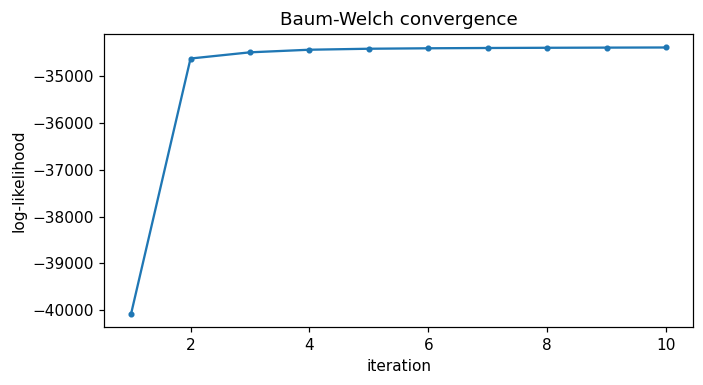

In [13]:
# Monotonicity check
hist = np.array(history)
deltas = np.diff(hist)
worst = float(deltas.min()) if len(deltas) else 0.0
print(f"final log-likelihood = {hist[-1]:.2f}")
print(f"worst LL decrease between iterations = {worst:.4f} "
      f"(should be near 0; small dips are tolerable due to numerical M-step)")

fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.6))
ax.plot(np.arange(1, len(hist) + 1), hist, marker="o", ms=3)
ax.set_xlabel("iteration"); ax.set_ylabel("log-likelihood")
ax.set_title("Baum-Welch convergence")
plt.tight_layout(); plt.show()


In [14]:
# Multi-start stability
np.random.seed(0)
def random_init():
    pi  = np.random.dirichlet([2, 1, 1])
    T   = np.array([np.random.dirichlet([8, 1, 1]),
                    np.random.dirichlet([3, 5, 1]),
                    np.random.dirichlet([2, 1, 6])])
    mu  = np.sort(np.random.uniform(0.02, 0.7, size=3))
    mu  = np.array([mu[0], mu[2], mu[1]])     # U(low), M(high), B(mid)
    kappa = np.random.uniform(10, 80, size=3)
    pd_ = np.random.uniform(0.1, 0.9, size=3)
    return HMMParams(pi=pi, T=T, mu=mu, kappa=kappa, p_drach=pd_)

multi_results = []
for run in range(4):
    np.random.seed(run + 1)
    p_init = random_init()
    p_fit, h = baum_welch(TR_train, p_init, n_iter=30, lam=1.0, tol=1e-4, verbose=False)
    multi_results.append((p_fit, h))
    print(f"restart {run+1}:  final LL = {h[-1]:12.2f}   "
          f"mu = {p_fit.mu}   p_drach_M = {p_fit.p_drach[1]:.3f}")

lls = np.array([h[-1] for _, h in multi_results])
print(f"\nLL spread across restarts: max - min = {lls.max() - lls.min():.2f}")


restart 1:  final LL =    -34366.90   mu = [0.0198 0.6897 0.2483]   p_drach_M = 0.584
restart 2:  final LL =    -34377.34   mu = [0.0198 0.6885 0.2473]   p_drach_M = 0.581
restart 3:  final LL =    -35338.97   mu = [0.0147 0.2976 0.0202]   p_drach_M = 0.150
restart 4:  final LL =    -34557.83   mu = [0.0196 0.2486 0.16  ]   p_drach_M = 0.071

LL spread across restarts: max - min = 972.06


### 5.4 ROC, PR, and F1 on held-out data with bootstrap confidence intervals

We score every test-set adenosine by its posterior $P(Z_t = M \mid O_{1:L})$
and compute ROC-AUC and PR-AUC. Confidence intervals are obtained by
**transcript-level bootstrap resampling** (1{,}000 replicates) — resampling
adenosines independently would be invalid because nearby positions on the same
transcript share the same artifact / coverage / sequence environment.

In [15]:
def score_test_set(transcripts, params):
    '''Return per-adenosine table with posterior P(M), P(B), P(U), and labels.'''
    rows = []
    for ti, tr in enumerate(transcripts):
        gamma, _ = posterior_states(tr, params)
        for i in tr.A_idx:
            rows.append((ti, i, tr.n[i], tr.A_count[i], tr.A_count[i] / max(tr.n[i], 1),
                         gamma[i, 0], gamma[i, 1], gamma[i, 2],
                         bool(tr.truth_m6a[i]), bool(tr.truth_artifact[i]), bool(tr.drach[i])))
    return pd.DataFrame(rows, columns=["tr","pos","n","k","Arate","pU","pM","pB",
                                       "truth_m6a","artifact","drach"])

df_test = score_test_set(TR_test, params_fit)
print(f"Test set: {len(TR_test)} transcripts, {len(df_test)} adenosines, "
      f"{int(df_test.truth_m6a.sum())} true m6A "
      f"({100 * df_test.truth_m6a.mean():.2f}%)")


Test set: 40 transcripts, 16338 adenosines, 166 true m6A (1.02%)


In [16]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

def bootstrap_metrics(df, score_col, n_boot=1000, seed=0):
    '''Transcript-level bootstrap of ROC-AUC and PR-AUC.'''
    rng = np.random.default_rng(seed)
    tr_ids = df["tr"].unique()
    aucs, aps = [], []
    for _ in range(n_boot):
        sample = rng.choice(tr_ids, size=len(tr_ids), replace=True)
        chunks = [df[df["tr"] == t] for t in sample]
        d = pd.concat(chunks, ignore_index=True)
        if d["truth_m6a"].sum() == 0 or d["truth_m6a"].sum() == len(d):
            continue
        aucs.append(roc_auc_score(d["truth_m6a"], d[score_col]))
        aps.append(average_precision_score(d["truth_m6a"], d[score_col]))
    return np.array(aucs), np.array(aps)


auc = roc_auc_score(df_test.truth_m6a, df_test.pM)
ap  = average_precision_score(df_test.truth_m6a, df_test.pM)
boot_auc, boot_ap = bootstrap_metrics(df_test, "pM", n_boot=1000, seed=0)
auc_lo, auc_hi = np.percentile(boot_auc, [2.5, 97.5])
ap_lo,  ap_hi  = np.percentile(boot_ap,  [2.5, 97.5])

print(f"HMM ROC-AUC = {auc:.4f}   95% bootstrap CI [{auc_lo:.4f}, {auc_hi:.4f}]")
print(f"HMM PR-AUC  = {ap:.4f}   95% bootstrap CI [{ap_lo:.4f}, {ap_hi:.4f}]")


HMM ROC-AUC = 0.9991   95% bootstrap CI [0.9976, 1.0000]
HMM PR-AUC  = 0.9848   95% bootstrap CI [0.9700, 0.9977]


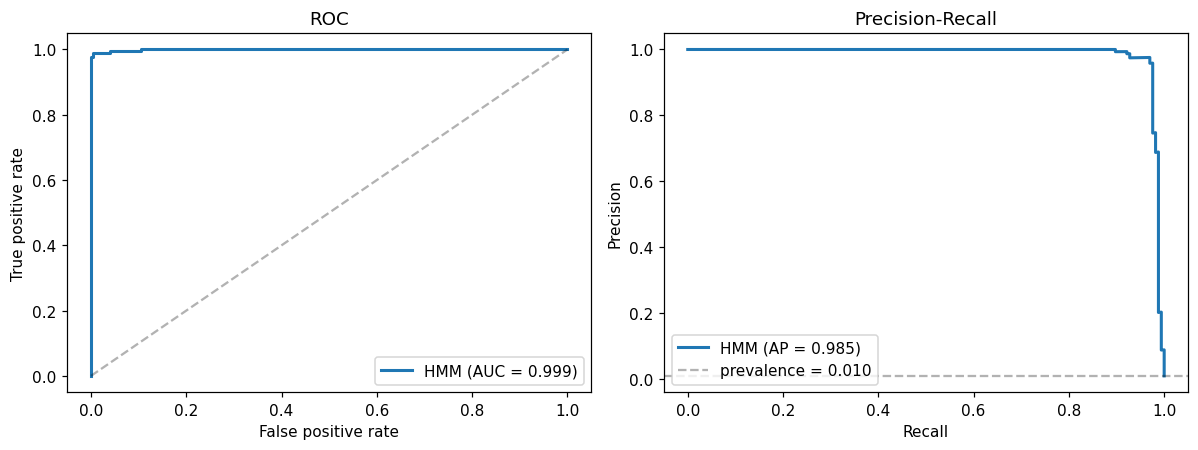

In [17]:
# Plot ROC and PR
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
fpr, tpr, _ = roc_curve(df_test.truth_m6a, df_test.pM)
ax[0].plot(fpr, tpr, label=f"HMM (AUC = {auc:.3f})", lw=2)
ax[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC"); ax[0].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(df_test.truth_m6a, df_test.pM)
ax[1].plot(rec, prec, label=f"HMM (AP = {ap:.3f})", lw=2)
base_rate = df_test.truth_m6a.mean()
ax[1].axhline(base_rate, color="k", ls="--", alpha=0.3, label=f"prevalence = {base_rate:.3f}")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall"); ax[1].legend(loc="lower left")
plt.tight_layout(); plt.show()


### 5.5 Threshold sweep and operating-point analysis

The paper recommends $\tau = 0.8$. We sweep $\tau$ and report precision,
recall, F1, and empirical FDR — both globally and after also enforcing the
$P(M) > P(B)$ constraint (Section 2.12) and the minimum-coverage filter
$n \geq 10$.

In [18]:
def call_at_threshold(df, tau, n_min=10, require_M_gt_B=True):
    call = (df["pM"] >= tau) & (df["n"] >= n_min)
    if require_M_gt_B:
        call &= (df["pM"] > df["pB"])
    truth = df["truth_m6a"].astype(bool)
    tp = int((call & truth).sum())
    fp = int((call & ~truth).sum())
    fn = int((~call & truth).sum())
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)
    fdr  = fp / max(tp + fp, 1)
    return dict(tau=tau, calls=tp + fp, TP=tp, FP=fp, FN=fn,
                precision=prec, recall=rec, F1=f1, FDR=fdr)


taus = np.arange(0.5, 0.99, 0.02)
sweep = pd.DataFrame([call_at_threshold(df_test, t) for t in taus])
print(sweep.round(4).to_string(index=False))


 tau  calls  TP  FP  FN  precision  recall     F1    FDR
0.50    139 136   3  30     0.9784  0.8193 0.8918 0.0216
0.52    139 136   3  30     0.9784  0.8193 0.8918 0.0216
0.54    139 136   3  30     0.9784  0.8193 0.8918 0.0216
0.56    139 136   3  30     0.9784  0.8193 0.8918 0.0216
0.58    139 136   3  30     0.9784  0.8193 0.8918 0.0216
0.60    139 136   3  30     0.9784  0.8193 0.8918 0.0216
0.62    139 136   3  30     0.9784  0.8193 0.8918 0.0216
0.64    139 136   3  30     0.9784  0.8193 0.8918 0.0216
0.66    139 136   3  30     0.9784  0.8193 0.8918 0.0216
0.68    137 134   3  32     0.9781  0.8072 0.8845 0.0219
0.70    137 134   3  32     0.9781  0.8072 0.8845 0.0219
0.72    137 134   3  32     0.9781  0.8072 0.8845 0.0219
0.74    137 134   3  32     0.9781  0.8072 0.8845 0.0219
0.76    137 134   3  32     0.9781  0.8072 0.8845 0.0219
0.78    137 134   3  32     0.9781  0.8072 0.8845 0.0219
0.80    137 134   3  32     0.9781  0.8072 0.8845 0.0219
0.82    137 134   3  32     0.9

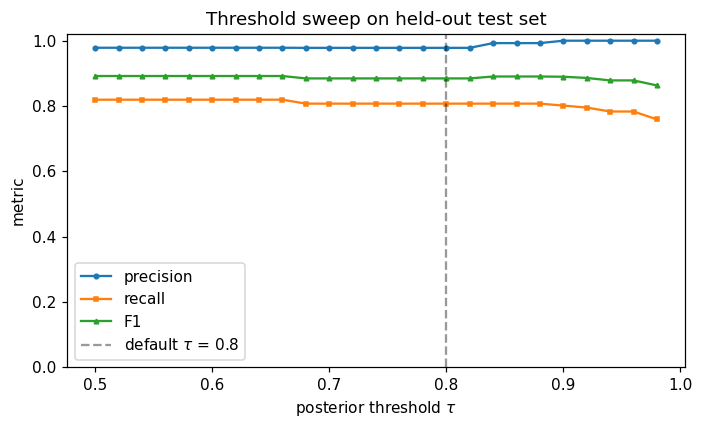

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.0))
ax.plot(sweep["tau"], sweep["precision"], "-o", ms=3, label="precision")
ax.plot(sweep["tau"], sweep["recall"],    "-s", ms=3, label="recall")
ax.plot(sweep["tau"], sweep["F1"],        "-^", ms=3, label="F1")
ax.axvline(0.8, color="k", ls="--", alpha=0.4, label=r"default $\tau$ = 0.8")
ax.set_xlabel(r"posterior threshold $\tau$")
ax.set_ylabel("metric")
ax.set_ylim(0, 1.02)
ax.set_title("Threshold sweep on held-out test set")
ax.legend()
plt.tight_layout()
plt.savefig("fig_threshold.pdf", bbox_inches="tight")  # PDF for LaTeX
plt.savefig("fig_threshold.png", dpi=300, bbox_inches="tight")  # PNG fallback
plt.show()


### 5.6 Stratified evaluation

Performance broken down by:

* **Coverage** ($n_t$ tertiles).
* **DRACH** vs. **non-DRACH** sequence context.
* **Inside** vs. **outside** simulated artifact regions.

This shows whether the method has systematic blind spots.

In [20]:
def stratified_metrics(df, mask, label, tau=0.8):
    sub = df[mask]
    if sub.empty or sub["truth_m6a"].sum() == 0:
        return dict(stratum=label, n=len(sub), n_pos=int(sub["truth_m6a"].sum()),
                    AUC=np.nan, AP=np.nan, F1=np.nan, FDR=np.nan)
    auc = roc_auc_score(sub["truth_m6a"], sub["pM"])
    ap  = average_precision_score(sub["truth_m6a"], sub["pM"])
    res = call_at_threshold(sub, tau)
    return dict(stratum=label, n=len(sub), n_pos=int(sub["truth_m6a"].sum()),
                AUC=auc, AP=ap, F1=res["F1"], FDR=res["FDR"])

# coverage tertiles
q1, q2 = np.quantile(df_test["n"], [1/3, 2/3])
strata = []
strata.append(stratified_metrics(df_test, df_test["n"] <= q1,  f"coverage low (n<={int(q1)})"))
strata.append(stratified_metrics(df_test, (df_test["n"] > q1) & (df_test["n"] <= q2),
                                 f"coverage mid"))
strata.append(stratified_metrics(df_test, df_test["n"] > q2,   f"coverage high (n>{int(q2)})"))
strata.append(stratified_metrics(df_test, df_test["drach"],     "DRACH"))
strata.append(stratified_metrics(df_test, ~df_test["drach"],    "non-DRACH"))
strata.append(stratified_metrics(df_test, df_test["artifact"],  "inside artifact region"))
strata.append(stratified_metrics(df_test, ~df_test["artifact"], "outside artifact region"))

stratified = pd.DataFrame(strata)
print(stratified.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


                stratum     n  n_pos    AUC     AP     F1    FDR
   coverage low (n<=19)  5716     63 0.9998 0.9895 0.7400 0.0000
           coverage mid  5231     57 1.0000 0.9966 0.9558 0.0357
   coverage high (n>34)  5391     46 0.9996 0.9782 0.9556 0.0227
                  DRACH  1124     94 0.9990 0.9942 0.9143 0.0123
              non-DRACH 15214     72 0.9985 0.9716 0.8437 0.0357
 inside artifact region   620      5 0.8741 0.3238 0.2222 0.7500
outside artifact region 15718    161 1.0000 0.9979 0.9048 0.0000


### 5.7 Ablation study

We retrain (or re-score) several stripped-down variants to measure how much
each modelling choice contributes:

* **No DRACH emission** – set $P(\text{DRACH} \mid z)$ uniform across states.
* **No artifact state** – fix $P(B) = 0$ at every position post-hoc and call
  on the U/M sub-model.
* **Binomial emission** instead of beta-binomial – $\kappa \to \infty$ limit.


In [21]:
def score_no_drach(transcripts, params):
    '''Re-score with the DRACH emission set to uniform across states (no signal).'''
    p2 = params.copy()
    p2.p_drach = np.array([0.5, 0.5, 0.5])      # neutral context
    df = score_test_set(transcripts, p2)
    return df


def score_no_artifact_state(df_full):
    '''Drop the B state: renormalise posterior over (U, M) only.'''
    df = df_full.copy()
    s = df["pU"] + df["pM"]
    df["pM"] = df["pM"] / s
    df["pU"] = df["pU"] / s
    df["pB"] = 0.0
    return df


def baum_welch_binomial(transcripts, params, n_iter=30, lam=1.0, tol=1e-4, verbose=False):
    '''Same as baum_welch but forces kappa -> very large, i.e. binomial limit.'''
    K = 3
    history = []
    prev_ll = -np.inf
    for it in range(n_iter):
        sum_pi = np.zeros(K)
        sum_xi = np.zeros((K, K))
        sum_gamma_A = np.zeros(K)
        sum_gamma_drach = np.zeros(K)
        all_k, all_n, all_w = [], [], [[] for _ in range(K)]
        total_logZ = 0.0
        log_pi = np.log(params.pi + 1e-300)
        log_T  = np.log(params.T  + 1e-300)
        for tr in transcripts:
            log_e = emission_logprob(tr, params)
            la, lb, lg, lZ = forward_backward(log_e, log_pi, log_T)
            total_logZ += lZ
            gamma = np.exp(lg)
            sum_pi += gamma[0]
            log_xi = la[:-1, :, None] + log_T[None, :, :] + (log_e[1:] + lb[1:])[:, None, :] - lZ
            sum_xi += np.exp(log_xi).sum(axis=0)
            if len(tr.A_idx):
                gA = gamma[tr.A_idx]
                sum_gamma_A += gA.sum(axis=0)
                sum_gamma_drach += gA[tr.drach[tr.A_idx]].sum(axis=0)
                all_k.append(tr.A_count[tr.A_idx]); all_n.append(tr.n[tr.A_idx])
                for z in range(K):
                    all_w[z].append(gA[:, z])
        pi_new = (sum_pi + lam) / (sum_pi.sum() + K * lam)
        T_new  = (sum_xi + lam) / (sum_xi.sum(axis=1, keepdims=True) + K * lam)
        p_drach_new = (sum_gamma_drach + lam) / (sum_gamma_A + 2 * lam)
        # binomial: weighted mean of p only; kappa fixed huge
        k_all = np.concatenate(all_k); n_all = np.concatenate(all_n)
        mu_new = np.empty(K)
        for z in range(K):
            w_z = np.concatenate(all_w[z])
            tot = np.sum(w_z * n_all)
            mu_new[z] = np.clip(np.sum(w_z * k_all) / max(tot, 1e-9), 1e-3, 1 - 1e-3)
        kappa_new = np.full(K, 1e4)             # binomial limit
        params = HMMParams(pi=pi_new, T=T_new, mu=mu_new, kappa=kappa_new, p_drach=p_drach_new)
        params = _enforce_state_order(params)
        history.append(total_logZ)
        if it > 0 and abs(total_logZ - prev_ll) < tol * max(1.0, abs(prev_ll)):
            break
        prev_ll = total_logZ
    return params, history


print("Training binomial-only variant...")
params_binom, _ = baum_welch_binomial(TR_train, HMMParams.default(), n_iter=30, verbose=False)
print(f"  binomial mu = {params_binom.mu}   p_drach = {params_binom.p_drach.round(3)}")


Training binomial-only variant...
  binomial mu = [0.0194 0.6897 0.2443]   p_drach = [0.064 0.569 0.073]


In [22]:
# Score every variant on the test set
df_full       = df_test                                   # full model (already scored)
df_no_drach   = score_no_drach(TR_test, params_fit)
df_no_artif   = score_no_artifact_state(df_full)
df_binom      = score_test_set(TR_test, params_binom)

def summarise(df, label, tau=0.8):
    auc = roc_auc_score(df["truth_m6a"], df["pM"])
    ap  = average_precision_score(df["truth_m6a"], df["pM"])
    res = call_at_threshold(df, tau)
    return dict(model=label, ROC_AUC=auc, PR_AUC=ap,
                F1=res["F1"], precision=res["precision"], recall=res["recall"], FDR=res["FDR"])

ablation = pd.DataFrame([
    summarise(df_full,     "Full HMM (beta-bin + DRACH + B state)"),
    summarise(df_no_drach, "No DRACH emission"),
    summarise(df_no_artif, "No artifact state (U/M only)"),
    summarise(df_binom,    "Binomial emission (kappa -> inf)"),
])
print(ablation.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


                                model  ROC_AUC  PR_AUC     F1  precision  recall    FDR
Full HMM (beta-bin + DRACH + B state)   0.9991  0.9848 0.8845     0.9781  0.8072 0.0219
                    No DRACH emission   0.9988  0.9838 0.8940     0.9926  0.8133 0.0074
         No artifact state (U/M only)   0.9984  0.8929 0.5602     0.4164  0.8554 0.5836
     Binomial emission (kappa -> inf)   0.9990  0.9832 0.8889     0.9714  0.8193 0.0286


### 5.8 Posterior calibration

The posterior $P(Z_t = M \mid O_{1:L})$ has a probabilistic interpretation —
it should match the empirical fraction of true m6A among adenosines whose
posterior falls in a given bin. We bin posteriors and compare predicted
vs. observed positive rate (a reliability diagram).

A perfectly calibrated classifier sits on the diagonal. Models that are
"overconfident" (posteriors too peaked at 0/1) bow below the diagonal at high
posterior; "underconfident" models bow above.

 bin  mean_pred  mean_obs  count
   0     0.0002    0.0002  16163
   1     0.1131    0.0000      6
   2     0.2359    0.2500      4
   4     0.4570    1.0000      3
   6     0.6713    1.0000      2
   7     0.7077    1.0000      2
   8     0.8624    0.4000      5
   9     0.9945    0.9935    153


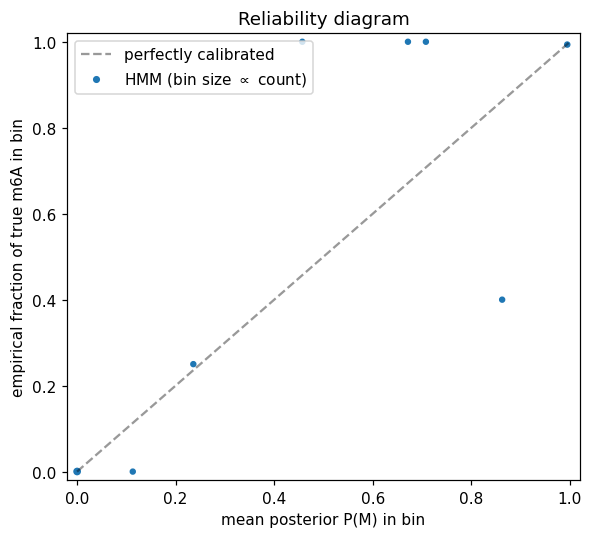

In [23]:
bins = np.linspace(0, 1, 11)
bin_id = np.digitize(df_test["pM"], bins) - 1
bin_id = np.clip(bin_id, 0, len(bins) - 2)
calib = (df_test.assign(bin=bin_id)
                .groupby("bin")
                .agg(mean_pred=("pM", "mean"),
                     mean_obs=("truth_m6a", "mean"),
                     count=("pM", "size"))
                .reset_index())
print(calib.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

fig, ax = plt.subplots(1, 1, figsize=(5.5, 5.0))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfectly calibrated")
ax.scatter(calib["mean_pred"], calib["mean_obs"],
           s=10 + 0.05 * np.sqrt(calib["count"]),
           color="C0", label="HMM (bin size $\\propto$ count)")
ax.set_xlabel("mean posterior P(M) in bin")
ax.set_ylabel("empirical fraction of true m6A in bin")
ax.set_title("Reliability diagram"); ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()


### 5.9 Robustness to data-generating-process misspecification

We re-evaluate the *same* trained model on test sets generated under
**different** simulator settings. This probes how sensitive the framework is
to the assumed artifact rate, m6A rate, and overdispersion.

In [24]:
def evaluate_under(setting_kwargs, label, params=None, seed_offset=2000, n_tr=30):
    if params is None:
        params = params_fit
    TR_alt = [simulate_transcript(L=1500, seed=seed_offset + i, **setting_kwargs) for i in range(n_tr)]
    df_alt = score_test_set(TR_alt, params)
    if df_alt["truth_m6a"].sum() == 0:
        return dict(setting=label, n_pos=0, AUC=np.nan, AP=np.nan, F1=np.nan, FDR=np.nan)
    auc = roc_auc_score(df_alt["truth_m6a"], df_alt["pM"])
    ap  = average_precision_score(df_alt["truth_m6a"], df_alt["pM"])
    res = call_at_threshold(df_alt, tau=0.8)
    return dict(setting=label, n_pos=int(df_alt["truth_m6a"].sum()),
                AUC=auc, AP=ap, F1=res["F1"], FDR=res["FDR"])

robust_rows = [
    evaluate_under({},                                    "baseline (matches training)"),
    evaluate_under({"artifact_rate": 0.10},               "high artifact rate (10%)"),
    evaluate_under({"artifact_rate": 0.01},               "low artifact rate (1%)"),
    evaluate_under({"p_m6a_at_drach_A": 0.02},            "rare m6A (1/5x)"),
    evaluate_under({"p_m6a_at_drach_A": 0.25},            "abundant m6A (2.5x)"),
    evaluate_under({"kappa_artifact": 8.0,
                    "kappa_clean": 20.0,
                    "kappa_m6a": 12.0},                   "high overdispersion"),
    evaluate_under({"cov_mean": 10.0},                    "low coverage (mean 10)"),
    evaluate_under({"cov_mean": 60.0},                    "high coverage (mean 60)"),
]
robustness = pd.DataFrame(robust_rows)
print(robustness.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


                    setting  n_pos    AUC     AP     F1    FDR
baseline (matches training)    134 1.0000 0.9984 0.9237 0.0000
   high artifact rate (10%)    135 0.9997 0.9918 0.9113 0.0000
     low artifact rate (1%)    144 1.0000 0.9995 0.9333 0.0000
            rare m6A (1/5x)     75 1.0000 0.9958 0.8971 0.0000
        abundant m6A (2.5x)    246 1.0000 0.9983 0.9234 0.0000
        high overdispersion    134 0.9995 0.9714 0.8664 0.0531
     low coverage (mean 10)    134 0.9986 0.9541 0.6327 0.0000
    high coverage (mean 60)    134 1.0000 0.9999 0.9572 0.0000


### 5.10 Comparison to a binomial-baseline caller (analogue of standard GLORI)

The baseline mirrors conventional GLORI site-calling:

1. Estimate a per-transcript A-to-G conversion background.
2. One-sided binomial test $P(X \geq A_t \mid n_t, p_g)$.
3. Benjamini–Hochberg FDR correction **restricted to testable sites** ($n_t \geq n_\min$),
   with threshold $q \leq 0.05$.
4. Empirical 10% A-rate floor.

We then compare it head-to-head with the HMM at $\tau = 0.8$.

In [25]:
from statsmodels.stats.multitest import multipletests

def binomial_baseline(transcripts, n_min=10, a_rate_floor=0.10, q_alpha=0.05):
    rows = []
    for ti, tr in enumerate(transcripts):
        rates = tr.A_count[tr.A_idx] / np.maximum(tr.n[tr.A_idx], 1)
        low = rates[rates < a_rate_floor]
        p_g = max(float(np.median(low)) if len(low) > 0 else 0.02, 0.005)
        for i in tr.A_idx:
            n = tr.n[i]; k = tr.A_count[i]
            testable = n >= n_min
            if not testable:
                rows.append((ti, i, n, k, k / max(n, 1), p_g, np.nan, False, testable,
                             tr.truth_m6a[i], tr.truth_artifact[i], tr.drach[i]))
                continue
            pval = 1.0 - binom.cdf(k - 1, n, p_g)
            pass_floor = (k / n) >= a_rate_floor
            rows.append((ti, i, n, k, k / n, p_g, pval, pass_floor, testable,
                         tr.truth_m6a[i], tr.truth_artifact[i], tr.drach[i]))
    df = pd.DataFrame(rows, columns=["tr","pos","n","k","Arate","p_g","pval",
                                     "pass_floor","testable",
                                     "truth_m6a","artifact","drach"])
    # BH-FDR over testable sites only
    df["qval"] = 1.0
    df["call"] = False
    mask = df["testable"]
    if mask.any():
        rej, qval, _, _ = multipletests(df.loc[mask, "pval"].values,
                                        alpha=q_alpha, method="fdr_bh")
        df.loc[mask, "qval"] = qval
        df.loc[mask, "call"] = rej & df.loc[mask, "pass_floor"]
    return df


df_bin = binomial_baseline(TR_test)

def metrics_from_call(df, call, score):
    truth = df["truth_m6a"].astype(bool).values
    auc = roc_auc_score(truth, score)
    ap  = average_precision_score(truth, score)
    tp = int((call & truth).sum())
    fp = int((call & ~truth).sum())
    fn = int((~call & truth).sum())
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)
    fdr  = fp / max(tp + fp, 1)
    return dict(ROC_AUC=auc, PR_AUC=ap, calls=tp + fp, TP=tp, FP=fp, FN=fn,
                precision=prec, recall=rec, F1=f1, empirical_FDR=fdr)

# Score arrays for ROC/PR
score_bin   = -np.log10(df_bin["qval"].fillna(1.0).values + 1e-300)
score_hmm   = df_test["pM"].values
call_bin    = df_bin["call"].values
call_hmm    = ((df_test["pM"] >= 0.8) & (df_test["pM"] > df_test["pB"]) & (df_test["n"] >= 10)).values

m_bin = metrics_from_call(df_bin,  call_bin,  score_bin)
m_hmm = metrics_from_call(df_test, call_hmm,  score_hmm)

comparison = pd.DataFrame([
    {"method": "Binomial baseline (BH q<=0.05, A>=10%)", **m_bin},
    {"method": "HMM (P(M)>=0.8, P(M)>P(B), n>=10)",       **m_hmm},
])
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


                                method  ROC_AUC  PR_AUC  calls  TP  FP  FN  precision  recall     F1  empirical_FDR
Binomial baseline (BH q<=0.05, A>=10%)   0.8969  0.3789   1071 142 929  24     0.1326  0.8554 0.2296         0.8674
     HMM (P(M)>=0.8, P(M)>P(B), n>=10)   0.9991  0.9848    137 134   3  32     0.9781  0.8072 0.8845         0.0219


In [26]:
# Where do baseline false positives come from?
fp_bin = call_bin & ~df_bin["truth_m6a"].values
fp_hmm = call_hmm & ~df_test["truth_m6a"].values

art_bin_fp = int((fp_bin & df_bin["artifact"].values).sum())
art_hmm_fp = int((fp_hmm & df_test["artifact"].values).sum())

artifact_summary = pd.DataFrame([
    {"method": "Binomial baseline",
     "FP total": int(fp_bin.sum()),
     "FP inside artifact": art_bin_fp,
     "% of FPs from artifact": 100 * art_bin_fp / max(int(fp_bin.sum()), 1)},
    {"method": "HMM",
     "FP total": int(fp_hmm.sum()),
     "FP inside artifact": art_hmm_fp,
     "% of FPs from artifact": 100 * art_hmm_fp / max(int(fp_hmm.sum()), 1)},
])
print(artifact_summary.to_string(index=False, float_format=lambda x: f"{x:.1f}"))


           method  FP total  FP inside artifact  % of FPs from artifact
Binomial baseline       929                 500                    53.8
              HMM         3                   3                   100.0


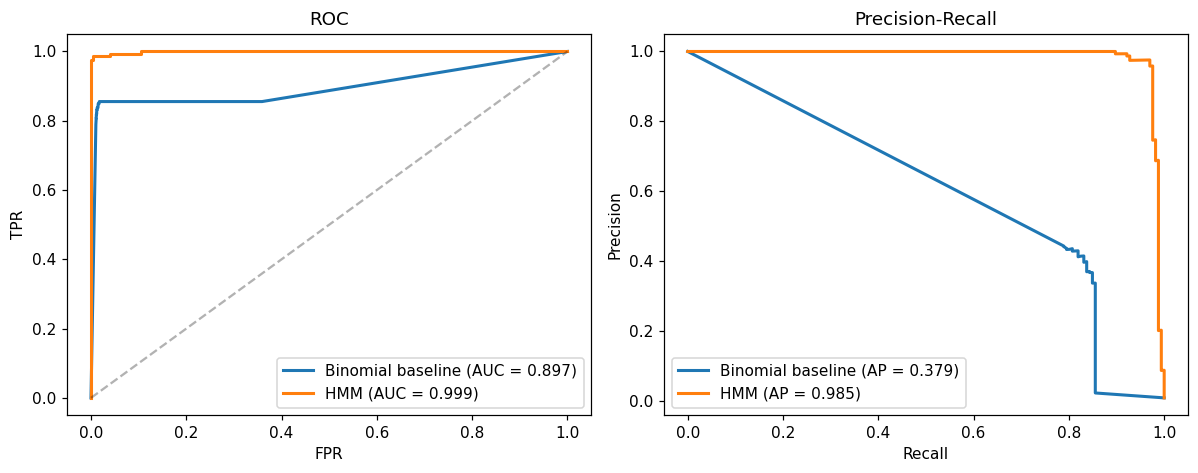

In [29]:
# Joint ROC/PR curves comparing the two methods
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for s, lbl in [(score_bin, "Binomial baseline"), (score_hmm, "HMM")]:
    fpr, tpr, _ = roc_curve(df_test["truth_m6a"], s)
    ax[0].plot(fpr, tpr, lw=2,
               label=f"{lbl} (AUC = {roc_auc_score(df_test['truth_m6a'], s):.3f})")
    p, r, _ = precision_recall_curve(df_test["truth_m6a"], s)
    ax[1].plot(r, p, lw=2,
               label=f"{lbl} (AP = {average_precision_score(df_test['truth_m6a'], s):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title("ROC"); ax[0].legend(loc="lower right")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].set_title("Precision-Recall"); ax[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig("fig_roc_pr.pdf", bbox_inches="tight")
plt.savefig("fig_roc_pr.png", dpi=300, bbox_inches="tight")
plt.show()


## Summary

In [28]:
print("="*72)
print("HEADLINE NUMBERS")
print("="*72)
n_test_A   = sum(len(t.A_idx) for t in TR_test)
n_test_m6a = sum(int(t.truth_m6a.sum()) for t in TR_test)
n_test_art = sum(int(t.truth_artifact[t.A_idx].sum()) for t in TR_test)
print(f"Train: {len(TR_train)} transcripts | Test: {len(TR_test)} transcripts, "
      f"{n_test_A} adenosines, {n_test_m6a} true m6A "
      f"({100 * n_test_m6a / n_test_A:.2f}%), {n_test_art} As inside artifact regions "
      f"({100 * n_test_art / n_test_A:.2f}%)")

print()
print("Method comparison:")
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()
print(f"HMM ROC-AUC = {auc:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")
print(f"HMM PR-AUC  = {ap:.4f}  95% CI [{ap_lo:.4f}, {ap_hi:.4f}]")

print()
print("Artifact-region false positives:")
print(artifact_summary.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

print()
print("Ablation study:")
print(ablation.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()
print("Stratified evaluation:")
print(stratified.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()
print("Robustness to misspecification:")
print(robustness.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()
print("Learned parameters (per-nucleotide HMM):")
print(f"  pi      = {params_fit.pi.round(3)}")
print(f"  mu      = {params_fit.mu.round(4)}")
print(f"  kappa   = {params_fit.kappa.round(1)}")
print(f"  p_drach = {params_fit.p_drach.round(3)}")
print(f"  T       =")
print(params_fit.T.round(3))


HEADLINE NUMBERS
Train: 60 transcripts | Test: 40 transcripts, 16338 adenosines, 166 true m6A (1.02%), 620 As inside artifact regions (3.79%)

Method comparison:
                                method  ROC_AUC  PR_AUC  calls  TP  FP  FN  precision  recall     F1  empirical_FDR
Binomial baseline (BH q<=0.05, A>=10%)   0.8969  0.3789   1071 142 929  24     0.1326  0.8554 0.2296         0.8674
     HMM (P(M)>=0.8, P(M)>P(B), n>=10)   0.9991  0.9848    137 134   3  32     0.9781  0.8072 0.8845         0.0219

HMM ROC-AUC = 0.9991  95% CI [0.9976, 1.0000]
HMM PR-AUC  = 0.9848  95% CI [0.9700, 0.9977]

Artifact-region false positives:
           method  FP total  FP inside artifact  % of FPs from artifact
Binomial baseline       929                 500                    53.8
              HMM         3                   3                   100.0

Ablation study:
                                model  ROC_AUC  PR_AUC     F1  precision  recall    FDR
Full HMM (beta-bin + DRACH + B state)   0.